# Iterative Quantum Phase Estimation

Quantum phase estimation is a core component in quantum algorithm/application development. One of the several variants of QPE includes the [iterative quantum phase estimation (IQPE)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.76.3228), which estimates the phase one bit at a time, starting from the least significant bit. Importantly, IQPE uses a single phase qubit that is used to estimate each bit of the true phase then is reset for the next iteration, making this variant cheaper in qubit count. For early generation QPUs where they may often by qubit-constrained, this version of QPE may be preferred!

For a nice figure of the IQPE, we refer the readers to [Fig. 2 of this work](https://arxiv.org/pdf/quant-ph/0610214).

In fact, quantum applications like phase estimating [Fermi-Hubbard using plaquette Trotterization](https://arxiv.org/abs/2012.09238) assumes this version of QPE.

In this notebook, we will demonstrate the IQPE using a simple phase unitary as the base iterate $U$.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from psiqworkbench import QPU, Qubits, Qubrick
from workbench_algorithms.subroutines.quantum_phase_estimation import IterativeQPE

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

Define the base unitary $U$:

In [3]:
class PhaseUnitary(Qubrick):
    """Test unitary for QPE.

    Args:
        phase (float): target phase value
    """
    def __init__(self, phase, **kwargs):
        if phase > 1 or phase < 0:
            raise ValueError('Phase should be between 0 and 1.')
        self.phase = phase
        super().__init__(**kwargs)

    def _compute(self, sys, ctrl=0):
        """Compute the dummy block encoding.

        Args:
            sys (Qubits): State register for the computation.
            ctrl (int, Qubits): Register to control the unitary on. Defaults to ``0``.
        """
        qc = self.get_qc()
        phase = self.phase

        theta = 2 * 180 * phase
        sys.phase(theta, ctrl)

We will now demonstrate the IQPE, reviewing two cases: (1) when the phase is exactly representable using some $n$ qubits in the phase register and (2) when it is not the case.

## Case 1: Exactly representable phase

Suppose the target/true phase is exactly representable with the precision qubits you've allocated for your QPE. Then IQPE will return the correct phase deterministically. 

In [4]:
phase = 1/2**3 + 1/2**2  # exactly representable using 4 bits
bits_of_precision = 4

In [5]:
# Repeat for multiple shots
results = []
n_trials = 100

for i in range(n_trials):

    qc = QPU()
    qc.reset(2)
    
    phase_reg = Qubits(1, 'phase_reg', qc)
    sys_reg = Qubits(1, 'sys_reg', qc)
    sys_reg.x()
    
    unitary = PhaseUnitary(phase)
    qpe = IterativeQPE(bits_of_precision, unitary)
    qpe.compute(sys_reg, phase_reg)
    phase_readout = qpe.get_classical_result('phase_readout')

    # Compute decimal representation of the phase estimate given outcome 
    val = 0
    for i, read_val in enumerate(phase_readout):
        val += (read_val / (1 << (len(phase_readout)-i)))
    results.append(val)

In [6]:
# Convert possible bitstrings to fixed point numbers
phase_vals = [
    i / (1 << bits_of_precision)
    for i in range(1 << bits_of_precision)
]

# Populate sample histogram
iqpe_outcomes = {}

for i in range(1 << bits_of_precision):
    iqpe_outcomes[phase_vals[i]] = 0

for key, val in Counter(results).items():
    if key in iqpe_outcomes.keys():
        iqpe_outcomes[key] = (val / n_trials)

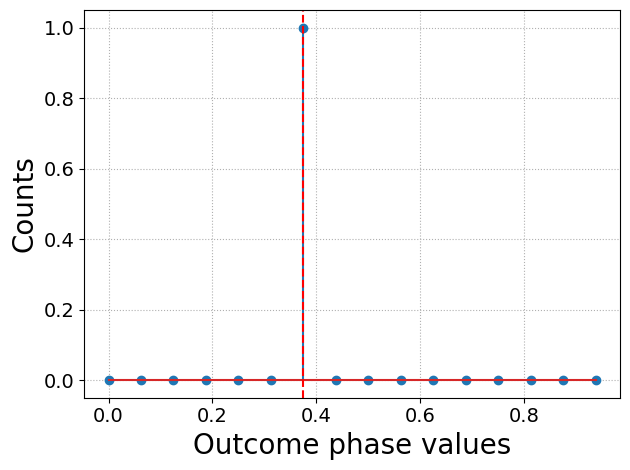

In [7]:
# Plot histogram
plt.stem(list(iqpe_outcomes.keys()), list(iqpe_outcomes.values()))

plt.axvline(phase, color='r', linestyle='--')
plt.grid(linestyle=':')

plt.xlabel('Outcome phase values', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()

## Case 2: phase is not exactly representable

Suppose the target/true phase is *not* exactly representable with the precision qubits you've allocated for your QPE. Then IQPE will return the nearest integer closest to the target phase with some high probability.

In [8]:
phase = 5/2**5
bits_of_precision = 4

In [9]:
# Repeat for multiple shots
results = []
n_trials = 300

for i in range(n_trials):

    qc = QPU()
    qc.reset(2)
    
    phase_reg = Qubits(1, 'phase_reg', qc)
    sys_reg = Qubits(1, 'sys_reg', qc)
    sys_reg.x()
    
    unitary = PhaseUnitary(phase)
    qpe = IterativeQPE(bits_of_precision, unitary)
    qpe.compute(sys_reg, phase_reg)
    phase_readout = qpe.get_classical_result('phase_readout')

    # Compute decimal representation of the phase estimate given outcome 
    val = 0
    for i, read_val in enumerate(phase_readout):
        val += (read_val / (1 << (len(phase_readout)-i)))
    results.append(val)

In [10]:
iqpe_outcomes = {}
phase_vals = [i /(1 << bits_of_precision) for i in range(1 << bits_of_precision)]
for i in range(1 << bits_of_precision):
    iqpe_outcomes[phase_vals[i]] = 0

for key, val in Counter(results).items():
    if key in iqpe_outcomes.keys():
        iqpe_outcomes[key] = val / n_trials

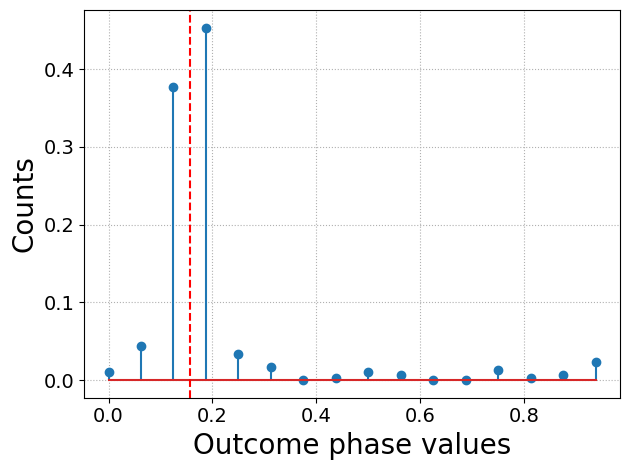

In [11]:
# Plot histogram
plt.stem(list(iqpe_outcomes.keys()), list(iqpe_outcomes.values()))

plt.axvline(phase, color='r', linestyle='--')
plt.grid(linestyle=':')

plt.xlabel('Outcome phase values', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()

Let's compare the histogram above to that outputted from the textbook QPE:

In [12]:
from psiqworkbench import QPU, QUInt, QUFixed, Qubrick, QFixed
from workbench_algorithms import (
    QPE)

In [13]:
# define some constants and set up unitary
unitary = PhaseUnitary(phase=phase)

# set up the quantum register
qc = QPU()
qc.reset(bits_of_precision + 1)
phase_reg = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qc)
sys_reg = Qubits(1, 'sys_reg', qc)
sys_reg.x()

# initialize the QPE qubrick
qpe = QPE(bits_of_precision=bits_of_precision, unitary=unitary)

# compute the QPE
qpe.compute(sys_reg, phase_reg)

In [14]:
probabilities = [
        phase_reg.peek_read_probability(i) for i in range(1 << bits_of_precision)
    ]

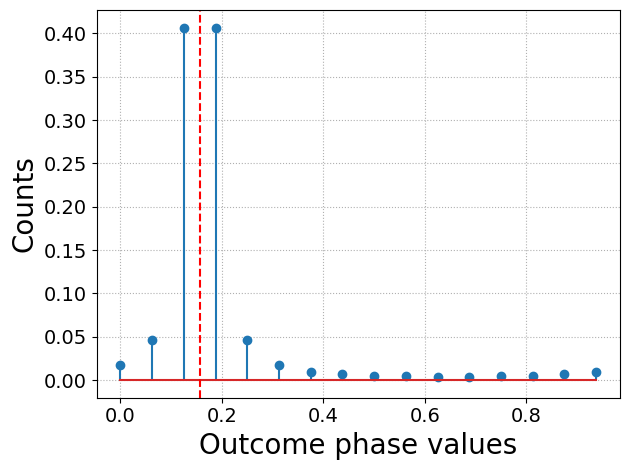

In [15]:
# Plot histogram
plt.stem(phase_vals, np.array(probabilities))

plt.axvline(phase, color='r', linestyle='--')
plt.grid(linestyle=':')

plt.xlabel('Outcome phase values', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()

In fact, the probability should be comparable/consistent with the one from the textbook version of QPE. The phase we considered above should be right in between two bins, which means the success probability (of landing on any of the two bins) should approach $8/\pi^2$ as we take more shots and with more bits of precision. Let's verify this.

In [16]:
# Take the top two bins from the histogram
counter = Counter(results)
closest_bins = counter.most_common(2)
closest_bins

[(0.1875, 136), (0.125, 113)]

We first check that the deviation from the true phase to either of the top two bins is equal to $1/2^{n+1}$ where $n$ is the number of phase qubits.

In [17]:
# Check that we've landed on the two top/nearest bins (these values should be equal)
abs(phase - closest_bins[0][0]), abs(closest_bins[1][0] - phase), 1/2**(bits_of_precision+1)

(0.03125, 0.03125, 0.03125)

In [18]:
# Add up the probabilities
succ_probability = (closest_bins[0][1] + closest_bins[1][1])/n_trials
succ_probability

0.83

Note that this value is close to $8/\pi^2 \approx 0.81$.

In [19]:
8/np.pi**2

0.8105694691387022

## How about when the phase is encoded between -1 and 1? 

In cases where the true phase is encoded between -1 and 1 (versus 0 and 1), the IQPE looks identical. The output bitstring is post-processed differently.

Below, we import the utils function for post-processing the outcome as a signed fixed point number.

In [20]:
def compute_dec_from_bitstring(bitstring_list, radix=None):
    """Compute signed fixed representation from bitstring.
    
    Args:
        bitstring_list (list): Binary list of bits starting from LSB to MSB (left to right)
        radix (int): radix of signed fixed point number
    """
    n = len(bitstring_list)
    if radix is None:
        radix = n - 1

    val = 0
    for i, k in enumerate(np.arange(len(bitstring_list)-1, -1, -1)):

        bit_val = bitstring_list[i]
        
        if i == 0:
            bit_val *= (-1)

        val += (bit_val * (2.**(k-radix)))

    return val

In [21]:
class PhaseUnitaryV2(Qubrick):
    """Test unitary for QPE.

    Args:
        phase (float): target phase value

    Note:
        - Phase value between -1 and 1
    """
    def __init__(self, phase, **kwargs):
        if phase > 1 or phase < -1:
            raise ValueError('Phase should be between -1 and 1.')
        self.phase = phase
        super().__init__(name="[PhaseUnitary]", **kwargs)

    def _compute(self, sys, ctrl=0):
        """Compute the dummy block encoding.

        Args:
            sys (Qubits): State register for the computation.
            ctrl (int, Qubits): Register to control the unitary on. Defaults to ``0``.
        """
        qc = self.get_qc()
        phase = self.phase

        # NOTE: phase can be from -1 to 1
        theta = 180 * phase
        sys.phase(theta, ctrl)

In [22]:
phase = -5/2**7
bits_of_precision = 4

In [23]:
# Repeat for multiple shots
results = []
n_trials = 300

for i in range(n_trials):

    qc = QPU()
    qc.reset(2)
    
    phase_reg = Qubits(1, 'phase_reg', qc)
    sys_reg = Qubits(1, 'sys_reg', qc)
    sys_reg.x()
    
    unitary = PhaseUnitaryV2(phase)
    qpe = IterativeQPE(bits_of_precision, unitary)
    qpe.compute(sys_reg, phase_reg)
    phase_readout = qpe.get_classical_result('phase_readout')

    # Post-process    
    estimate_val = compute_dec_from_bitstring(phase_readout[::-1], radix=None)

    results.append(estimate_val)

In [24]:
# Convert all possible bitstrings to signed fixed point numbers
phase_vals = [
    compute_dec_from_bitstring([int(d) for d in format(i, f'0{bits_of_precision}b')], radix=None)
    for i in range(1 << bits_of_precision)
]

# Populate sample histogram
iqpe_outcomes = {}

for i in range(1 << bits_of_precision):
    iqpe_outcomes[phase_vals[i]] = 0

for key, val in Counter(results).items():
    if key in iqpe_outcomes.keys():
        iqpe_outcomes[key] = (val / n_trials)

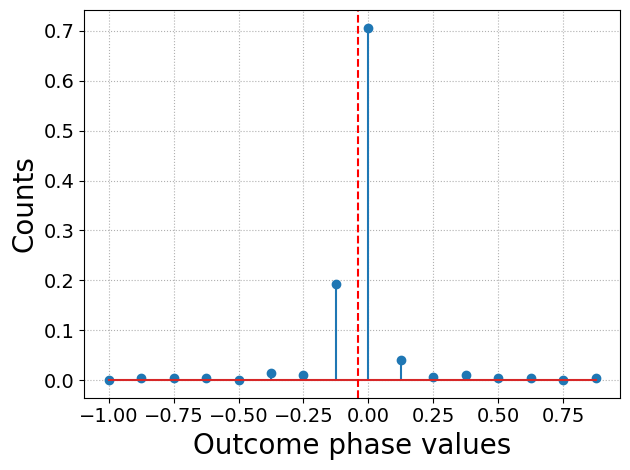

In [25]:
# Plot histogram
x = list(iqpe_outcomes.keys())
y = list(iqpe_outcomes.values())
plt.stem(x, y)

plt.axvline(phase, color='r', linestyle='--')
plt.grid(linestyle=':')

plt.xlabel('Outcome phase values', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()

If we run the textbook QPE...

In [26]:
# define some constants and set up unitary
unitary = PhaseUnitaryV2(phase=phase)

# set up the quantum register
qc = QPU()
qc.reset(bits_of_precision + 1)
phase_reg = QFixed(bits_of_precision, bits_of_precision-1, "phase_reg", qc)
sys_reg = Qubits(1, 'sys_reg', qc)
sys_reg.x()

# initialize the QPE qubrick
qpe = QPE(bits_of_precision=bits_of_precision, unitary=unitary)

# compute the QPE
qpe.compute(sys_reg, phase_reg)

probabilities = [
        phase_reg.peek_read_probability(i) for i in range(1 << bits_of_precision)
    ]

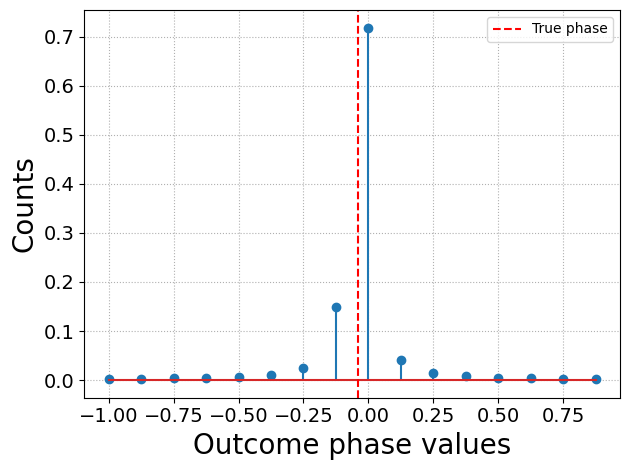

In [27]:
# Plot histogram
plt.stem(phase_vals, np.array(probabilities))

plt.axvline(phase, color='r', linestyle='--', label='True phase')
plt.grid(linestyle=':')

plt.xlabel('Outcome phase values', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()

plt.tight_layout()

We see that the histograms are very similar!